In [1]:
import os, warnings, json, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 컬럼 정의 ─────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']

print('✅ 라이브러리 로드 완료')


✅ 라이브러리 로드 완료


In [2]:
# FD002 원본 데이터 로딩
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD002.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD002.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD002.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD002.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename(columns=RENAME_MAP,  inplace=True)

print(f'✅ FD002 로딩  Train:{train_raw.shape}  Test:{test_raw.shape}  RUL:{rul_df.shape}')


✅ FD002 로딩  Train:(53759, 26)  Test:(33991, 26)  RUL:(259, 1)


In [3]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # 센서 추가 수동 제거 (예: ['s_5','s_9']). 빈 리스트면 자동제거만 적용
    'manual_remove_sensors': ['s_16'],

    # RUL Cap (120 / 125 / 130)
    'rul_cap': 125,

    # Gaussian sigma (None=skip / 1 / 2 / 3)
    'gaussian_sigma': 2,

    # 정규화 방식 ('minmax' / 'standard')
    'normalize': 'minmax',

    # ── 시계열 파생변수 (원하는 만큼 리스트로) ──
    'lags':         [10],     # 예: [] / [1] / [1,2] / [1,3,5,10] ...
    'diffs':        [1],           # 차분 윈도우
    'rolling_means':[5],        # rolling mean 윈도우들
    'rolling_stds': [10],        # rolling std 윈도우들
    'emas':         [10],           # EMA span (정수)
}

# 슬라이딩 윈도우 (DL 용)
WINDOW_SIZE = 30
STEP        = 1

# 클러스터 / 기타 상수
N_CLUSTERS = 6
CONST_THR  = 0.01
RANDOM_STATE = 42
VALID_RATIO  = 0.2

print('✅ CONFIG 로드 완료')
for k,v in CONFIG.items():
    print(f'   {k:22s}: {v}')


✅ CONFIG 로드 완료
   manual_remove_sensors : ['s_16']
   rul_cap               : 125
   gaussian_sigma        : 2
   normalize             : minmax
   lags                  : [10]
   diffs                 : [1]
   rolling_means         : [5]
   rolling_stds          : [10]
   emas                  : [10]


In [4]:
# ============================================================
# 🔧 파이프라인 함수 정의 (최적화 및 통합본)
# ============================================================

def filter_useful_sensors(train_df, sensor_cols, manual_remove, const_thr=CONST_THR):
    """상수 센서 자동 제거 + 수동 제거 = 최종 유용 센서 리스트"""
    train_std = train_df[sensor_cols].std()
    auto_remove = set(train_std[train_std < const_thr].index.tolist())
    manual_set  = set(manual_remove or [])
    remove = sorted(auto_remove | manual_set, key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    useful = sorted([s for s in sensor_cols if s not in remove],
                    key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    return useful, remove


def add_op_cluster(train_df, test_df, op_cols, k, random_state=42):
    """설정값(Setting) 스케일링 후 KMeans 클러스터링 수행"""
    op_scaler = MinMaxScaler()
    Xz_tr = op_scaler.fit_transform(train_df[op_cols])
    Xz_te = op_scaler.transform(test_df[op_cols])
    
    km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
    km.fit(Xz_tr)
    
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df['op_cluster'] = km.labels_
    test_df['op_cluster'] = km.predict(Xz_te)
    
    return train_df, test_df, km, op_scaler


def add_piecewise_rul(df, cap):
    """엔진별 RUL 계산 후 cap 적용"""
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


def apply_gaussian_by_cluster(df, features, sigma):
    """그룹별(엔진+클러스터) 가우시안 스무딩 (벡터화 최적화)"""
    df = df.copy().sort_values(['unit_nr', 'op_cluster', 'time_cycles']).reset_index(drop=True)
    
    def _smooth_func(s):
        if len(s) > 1:
            return gaussian_filter1d(s.values.astype(np.float32), sigma=sigma, mode='nearest')
        return s.values
        
    for col in features:
        df[col] = df.groupby(['unit_nr', 'op_cluster'])[col].transform(_smooth_func)
    return df


def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """엔진단위 random split"""
    units = train_df['unit_nr'].unique()
    sub_units, val_units = train_test_split(units, test_size=valid_ratio,
                                            random_state=random_state)
    sub = train_df[train_df['unit_nr'].isin(sub_units)].copy().reset_index(drop=True)
    val = train_df[train_df['unit_nr'].isin(val_units)].copy().reset_index(drop=True)
    return sub, val, sub_units, val_units


def normalize_by_cluster(sub, val, test, features, method, n_clusters):
    """클러스터별 정규화 (sub-train 기반 fit)"""
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    scalers = {}
    sub = sub.copy(); val = val.copy(); test = test.copy()
    
    for c in range(n_clusters):
        mask = sub['op_cluster'] == c
        scaler_c = ScalerCls()
        if mask.sum() > 0:
            sub.loc[mask, features] = scaler_c.fit_transform(sub.loc[mask, features])
            scalers[c] = scaler_c
        else:
            # 해당 클러스터에 데이터가 없는 경우(드문 경우) 대비
            scalers[c] = None 
            
    for df_target in [val, test]:
        for c in range(n_clusters):
            mask = df_target['op_cluster'] == c
            if mask.sum() > 0 and scalers[c] is not None:
                df_target.loc[mask, features] = scalers[c].transform(df_target.loc[mask, features])
    return sub, val, test, scalers


def add_temporal_features_by_cluster(df, sensor_cols, lags, diffs, rolls, roll_stds, emas):
    """엔진×클러스터 단위 시계열 파생변수 동적 생성"""
    df = df.copy().sort_values(['unit_nr', 'op_cluster', 'time_cycles'])
    
    for s in sensor_cols:
        grp = df.groupby(['unit_nr', 'op_cluster'])[s]
        for lag in (lags or []):
            df[f'{s}_lag{lag}'] = grp.shift(lag)
        for d in (diffs or []):
            df[f'{s}_diff{d}'] = grp.diff(d)
        for r in (rolls or []):
            df[f'{s}_roll{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).mean())
        for r in (roll_stds or []):
            df[f'{s}_rollstd{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).std().fillna(0))
        for span in (emas or []):
            df[f'{s}_ema{span}'] = grp.transform(lambda x: x.ewm(span=span, adjust=False).mean())
            
    return df.fillna(0)


def add_ohe_cluster(df, n_clusters):
    """op_cluster 원핫인코딩"""
    ohe_cols = [f'cluster_{i}' for i in range(n_clusters)]
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols:
        if col not in ohe.columns:
            ohe[col] = np.float32(0.0)
    return pd.concat([df.reset_index(drop=True),
                      ohe[ohe_cols].reset_index(drop=True)], axis=1), ohe_cols


def run_pipeline(train_raw, test_raw, cfg):
    """전체 파이프라인 실행 통합 로직"""
    
    # 1. 센서 필터링
    useful, removed = filter_useful_sensors(train_raw, SENSOR_COLS, cfg['manual_remove_sensors'])
    print(f'[1] 센서 필터링: 유지 {len(useful)}개 / 제거 {len(removed)}개')

    keep = ID_COLS + OP_COLS + useful
    tr1 = train_raw[keep].copy()
    te1 = test_raw[keep].copy()

    # 2. 클러스터링
    tr2, te2, kmeans, op_scaler = add_op_cluster(tr1, te1, OP_COLS, N_CLUSTERS, RANDOM_STATE)
    print(f'[2] 운전조건 클러스터링 완료 (k={N_CLUSTERS})')

    # 3. Piecewise RUL
    tr3 = add_piecewise_rul(tr2, cap=cfg['rul_cap'])
    te3 = te2.copy()
    print(f'[3] Piecewise RUL 적용 (cap={cfg["rul_cap"]})')

    # 4. Gaussian Smoothing
    if cfg.get('gaussian_sigma') and cfg['gaussian_sigma'] > 0:
        tr4 = apply_gaussian_by_cluster(tr3, useful, sigma=cfg['gaussian_sigma'])
        te4 = apply_gaussian_by_cluster(te3, useful, sigma=cfg['gaussian_sigma'])
        print(f'[4] Gaussian σ={cfg["gaussian_sigma"]} 적용')
    else:
        tr4, te4 = tr3, te3
        print('[4] Gaussian skip')

    # 5. Split
    sub5, val5, sub_units, val_units = split_by_unit(tr4, VALID_RATIO, RANDOM_STATE)
    test5 = te4.copy()
    print(f'[5] 데이터 분할: sub={len(sub_units)}대 / val={len(val_units)}대')

    # 6. 정규화
    sub6, val6, test6, scalers = normalize_by_cluster(sub5, val5, test5, useful, cfg['normalize'], N_CLUSTERS)
    print(f'[6] 클러스터별 정규화 완료 ({cfg["normalize"]})')

    # 7. 시계열 파생변수 (수정됨: sub6, val6, test6 각각 참조)
    sub7 = add_temporal_features_by_cluster(sub6, useful, cfg['lags'], cfg['diffs'], 
                                            cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    val7 = add_temporal_features_by_cluster(val6, useful, cfg['lags'], cfg['diffs'], 
                                            cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    test7 = add_temporal_features_by_cluster(test6, useful, cfg['lags'], cfg['diffs'], 
                                             cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    
    EXCLUDE = set(ID_COLS + OP_COLS + ['op_cluster', 'RUL', 'RUL_raw'])
    ml_features = [c for c in sub7.columns if c not in EXCLUDE]
    print(f'[7] 파생변수 생성 완료 (기본 features={len(ml_features)}개)')

    # 8. 원핫인코딩 추가
    sub8, ohe_cols = add_ohe_cluster(sub7, N_CLUSTERS)
    val8, _        = add_ohe_cluster(val7, N_CLUSTERS)
    test8, _       = add_ohe_cluster(test7, N_CLUSTERS)
    
    final_features = ml_features + ohe_cols
    print(f'[8] OHE 추가 완료 (최종 ML features={len(final_features)}개)')

    return {
        'subtrain_ml': sub8, 'valid_ml': val8, 'test_ml': test8,
        'ml_features': final_features, 'kmeans': kmeans, 'op_scaler': op_scaler, 'scalers': scalers
    }

print('✅ 통합 파이프라인 함수 정의 완료')

✅ 통합 파이프라인 함수 정의 완료


In [5]:
# ============================================================
# 🚀 파이프라인 실행 (최적화 및 통합본 대응)
# ============================================================
# 1. 파이프라인 실행
data = run_pipeline(train_raw, test_raw, CONFIG)

# 2. 결과 데이터 추출
train_ml    = data['subtrain_ml']
valid_ml    = data['valid_ml']
test_ml     = data['test_ml']
ML_FEATURES = data['ml_features']

# 3. 추가 정보 추출 (필요 시 사용)
kmeans_model = data['kmeans']
op_scaler    = data['op_scaler']
scalers_dict = data['scalers']

# 4. 결과 출력
print(f'\n[실행 결과]')
print(f'  - Sub-train 형태: {train_ml.shape}')
print(f'  - Valid 형태:     {valid_ml.shape}')
print(f'  - Test 형태:      {test_ml.shape}')
print(f'  - 최종 ML 피처 수: {len(ML_FEATURES)}개')

# 5. 피처 리스트 확인 (상위 10개만)
print(f'  - 주요 피처 예시: {ML_FEATURES[:10]}...')

[1] 센서 필터링: 유지 20개 / 제거 1개
[2] 운전조건 클러스터링 완료 (k=6)
[3] Piecewise RUL 적용 (cap=125)
[4] Gaussian σ=2 적용
[5] 데이터 분할: sub=208대 / val=52대
[6] 클러스터별 정규화 완료 (minmax)
[7] 파생변수 생성 완료 (기본 features=120개)
[8] OHE 추가 완료 (최종 ML features=126개)

[실행 결과]
  - Sub-train 형태: (43464, 134)
  - Valid 형태:     (10295, 134)
  - Test 형태:      (33991, 132)
  - 최종 ML 피처 수: 126개
  - 주요 피처 예시: ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10']...


In [6]:
# 흩어진 데이터를 다시 엔진-사이클 순으로 정렬
train_ml = train_ml.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
valid_ml = valid_ml.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
test_ml  = test_ml.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)

In [15]:
train_ml

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_21_diff1,s_21_roll5,s_21_rollstd10,s_21_ema10,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
0,1,1,34.9983,0.8400,100.0,0.0,0.244781,0.206650,0.491512,0.0,...,0.000000,0.465305,0.000000,0.465305,0.0,0.0,0.0,0.0,0.0,1.0
1,1,2,41.9982,0.8408,100.0,0.0,0.451599,0.324085,0.379395,0.0,...,0.000000,0.481092,0.000000,0.481092,1.0,0.0,0.0,0.0,0.0,0.0
2,1,3,24.9988,0.6218,60.0,0.0,0.582336,0.318214,0.362766,0.0,...,0.000000,0.711624,0.000000,0.711624,0.0,0.0,1.0,0.0,0.0,0.0
3,1,4,42.0077,0.8416,100.0,0.0,0.417816,0.307327,0.385498,0.0,...,0.084795,0.523490,0.059959,0.496510,1.0,0.0,0.0,0.0,0.0,0.0
4,1,5,25.0005,0.6203,60.0,0.0,0.518402,0.368515,0.377529,0.0,...,-0.051886,0.685681,0.036689,0.702190,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43459,260,312,20.0037,0.7000,100.0,0.0,0.825104,0.736130,0.800440,0.0,...,-0.035263,0.307296,0.084249,0.361069,0.0,0.0,0.0,1.0,0.0,0.0
43460,260,313,10.0022,0.2510,100.0,0.0,0.784607,0.826164,0.770006,0.0,...,-0.044754,0.323717,0.092988,0.372725,0.0,0.0,0.0,0.0,1.0,0.0
43461,260,314,25.0041,0.6200,60.0,0.0,0.808136,0.805328,0.779823,0.0,...,-0.080729,0.365176,0.100353,0.402516,0.0,0.0,1.0,0.0,0.0,0.0
43462,260,315,25.0033,0.6220,60.0,0.0,0.876129,0.842548,0.820129,0.0,...,-0.084965,0.299370,0.132264,0.355609,0.0,0.0,1.0,0.0,0.0,0.0


In [7]:
# ML 전용 라이브러리
import time
import joblib
import optuna
import mlflow
import mlflow.sklearn
import shap
import seaborn as sns

from optuna.samplers import TPESampler
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('✅ ML 라이브러리 로드 완료')

✅ ML 라이브러리 로드 완료


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve

# --- 1. 데이터 준비 (X, y 분리 및 Test 세트 구성) ---
X_train, y_train = train_ml[ML_FEATURES], train_ml['RUL']
X_val, y_val = valid_ml[ML_FEATURES], valid_ml['RUL']

# Test 평가는 각 엔진의 '마지막 사이클'만 추출하여 수행
test_last = test_ml.groupby('unit_nr').last().reset_index()
X_test = test_last[ML_FEATURES]
y_test = rul_df['RUL'].values 

# --- 2. NASA Score 함수 ---
def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

# --- 3. 통합 시각화 함수 (6개 그래프) ---
def evaluate_full_pipeline(model, model_name, is_tree=False, is_boosting=False, eval_results=None):
    # 예측
    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)
    
    # 지표 계산
    results = {
        'Train': [np.sqrt(mean_squared_error(y_train, pred_train)), calculate_nasa_score(y_train, pred_train)],
        'Valid': [np.sqrt(mean_squared_error(y_val, pred_val)), calculate_nasa_score(y_val, pred_val)],
        'Test':  [np.sqrt(mean_squared_error(y_test, pred_test)), calculate_nasa_score(y_test, pred_test)]
    }
    
    print(f"\n" + "="*50 + f"\n 🏆 {model_name} 최종 평가 결과 \n" + "="*50)
    for k, v in results.items():
        print(f" [{k}] RMSE: {v[0]:.4f} | NASA Score: {v[1]:.2f}")
    
    # 시각화 (2x3)
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    plt.subplots_adjust(hspace=0.3)
    
    # (1) Learning Curve
    ax1 = axes[0, 0]
    if is_boosting and eval_results:
        ax1.plot(eval_results['train'], label='Train RMSE')
        ax1.plot(eval_results['valid'], label='Valid RMSE')
        ax1.set_xlabel('Iterations')
    else:
        sizes, t_scores, v_scores = learning_curve(model, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error')
        ax1.plot(sizes, -np.mean(t_scores, axis=1), 'o-', label='Train RMSE')
        ax1.plot(sizes, -np.mean(v_scores, axis=1), 'o-', label='Valid RMSE')
        ax1.set_xlabel('Training Samples')
    ax1.set_title('1. Learning/Loss Curve')
    ax1.legend(); ax1.grid(True)

    # (2) Residual Plot (Validation)
    axes[0, 1].scatter(pred_val, y_val - pred_val, alpha=0.3, color='orange')
    axes[0, 1].axhline(0, color='red', linestyle='--')
    axes[0, 1].set_title('2. Residual Plot (Validation)')

    # (3) Feature Importance
    ax3 = axes[0, 2]
    imp = model.feature_importances_ if is_tree else np.abs(model.coef_)
    idx = np.argsort(imp)[-15:]
    ax3.barh(range(15), imp[idx], color='teal')
    ax3.set_yticks(range(15)); ax3.set_yticklabels(np.array(ML_FEATURES)[idx])
    ax3.set_title('3. Top 15 Features')

    # (4) Target vs Prediction Distribution (Validation)
    sns.kdeplot(y_val, label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(pred_val, label='Pred', ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('4. Target Distribution (Val)'); axes[1, 0].legend()

    # (5) Weight/Importance Histogram
    axes[1, 1].hist(imp, bins=30, color='purple', alpha=0.7)
    axes[1, 1].set_title('5. Feature Weight Histogram')

    # (6) [NEW] Test Actual vs Prediction Line Graph
    ax6 = axes[1, 2]
    ax6.plot(y_test, label='Actual RUL', color='black', linewidth=1.5)
    ax6.plot(pred_test, label='Predicted RUL', color='red', linestyle='--', alpha=0.8)
    ax6.set_title('6. Test: Actual vs Predicted Line Graph')
    ax6.set_xlabel('Engine Unit (Index)'); ax6.set_ylabel('RUL')
    ax6.legend(); ax6.grid(True)
    
    plt.show()


 🏆 Ridge 최종 평가 결과 
 [Train] RMSE: 14.6017 | NASA Score: 145223.08
 [Valid] RMSE: 14.4485 | NASA Score: 36749.49
 [Test] RMSE: 29.3143 | NASA Score: 8502.54


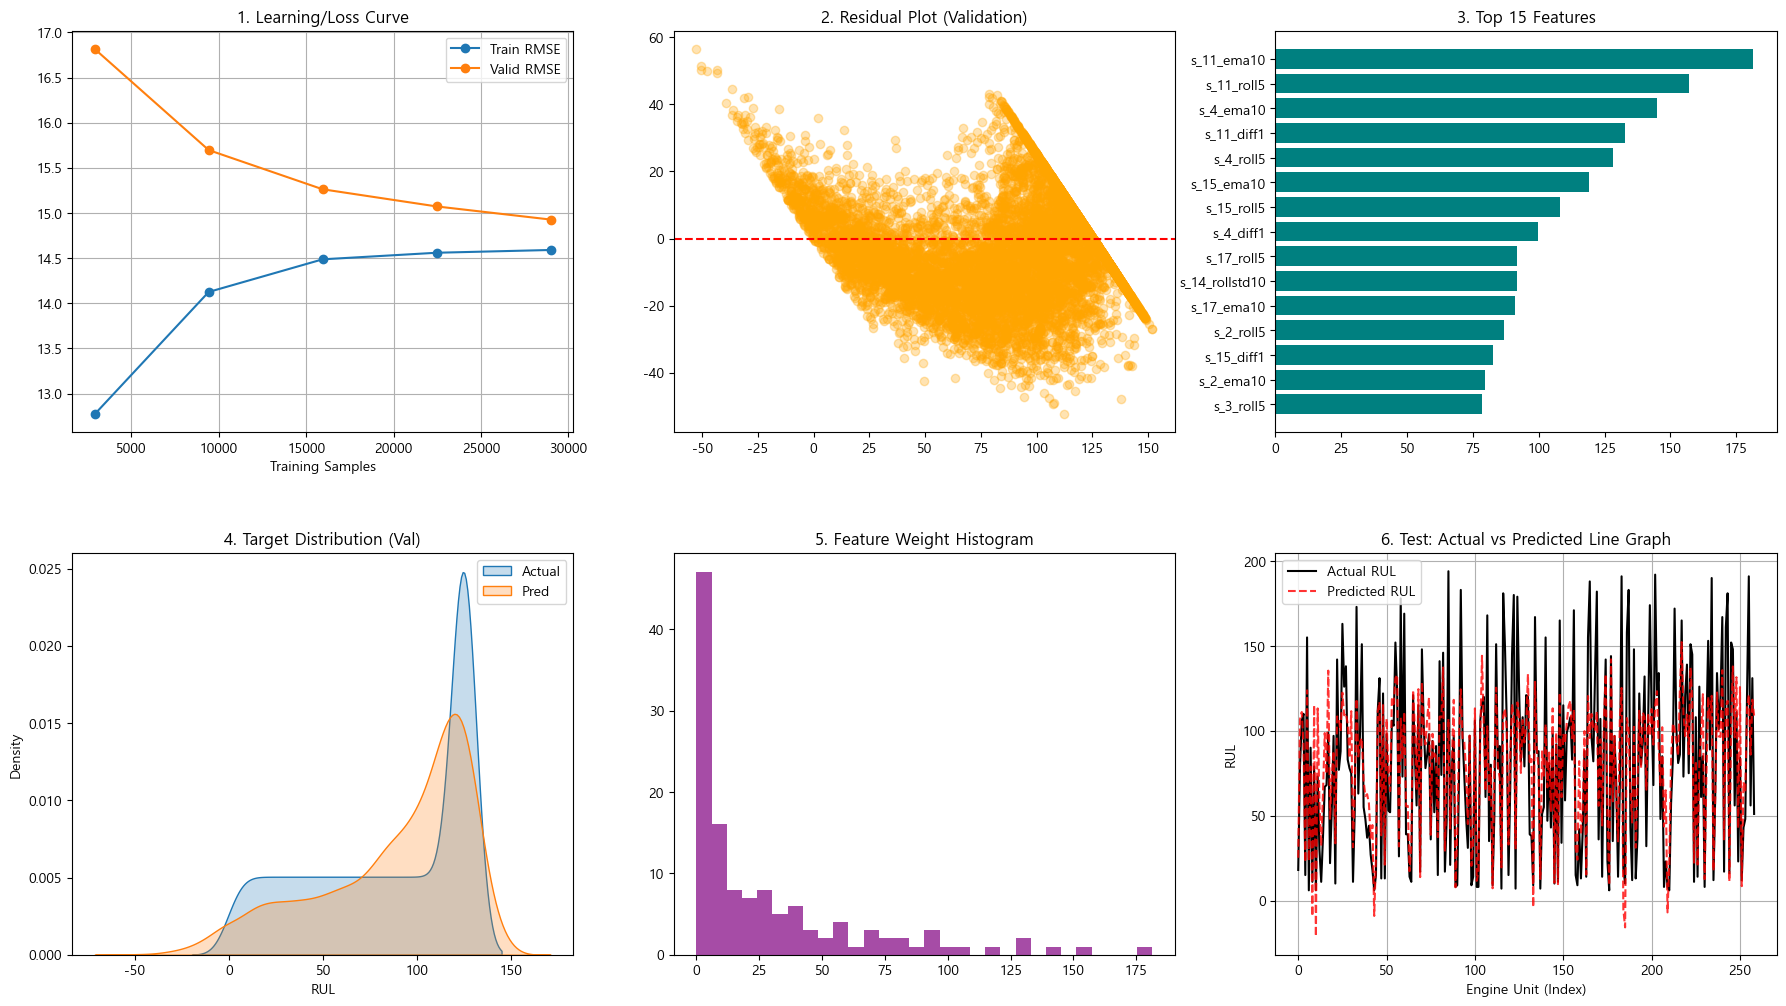

In [9]:
from sklearn.linear_model import Ridge

# --- 하이퍼파라미터 설정 ---
ridge_params = {
    'alpha': 1.0,           # 규제 강도 (클수록 규제 강화)
    'solver': 'auto',       # 최적화 알고리즘 ('auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga')
    'max_iter': 2000,       # 최대 반복 횟수
    'tol': 0.0001,          # 수렴 기준
    'random_state': 42
}

# 모델 초기화 및 학습
model_ridge = Ridge(**ridge_params)
model_ridge.fit(X_train, y_train)

# 평가 및 시각화
evaluate_full_pipeline(model_ridge, "Ridge")


 🏆 Lasso 최종 평가 결과 
 [Train] RMSE: 17.2081 | NASA Score: 210107.84
 [Valid] RMSE: 16.4826 | NASA Score: 47694.74
 [Test] RMSE: 31.1783 | NASA Score: 13839.33


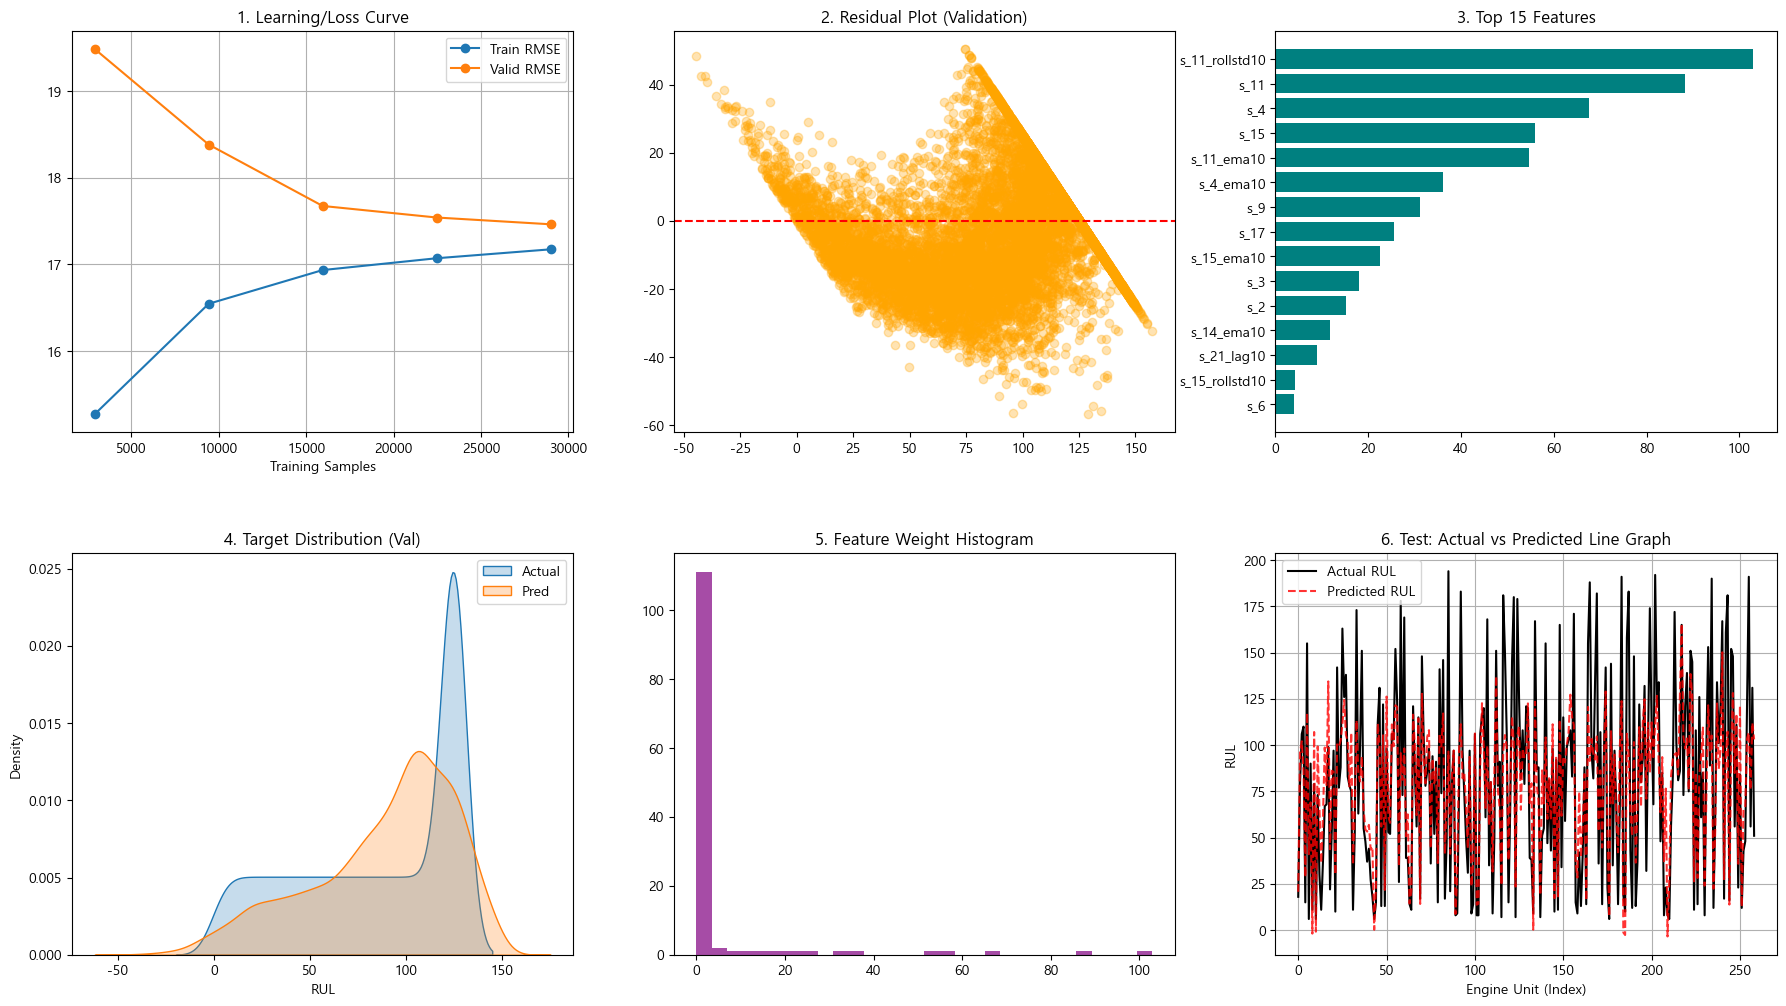

In [10]:
from sklearn.linear_model import Lasso

# --- 하이퍼파라미터 설정 ---
lasso_params = {
    'alpha': 0.1,           # 규제 강도 (불필요한 피처의 가중치를 0으로 만듦)
    'selection': 'cyclic',  # 가중치 업데이트 방식 ('cyclic', 'random')
    'max_iter': 2000,       # 최대 반복 횟수
    'tol': 0.0001,          # 수렴 기준
    'random_state': 42
}

# 모델 초기화 및 학습
model_lasso = Lasso(**lasso_params)
model_lasso.fit(X_train, y_train)

# 평가 및 시각화
evaluate_full_pipeline(model_lasso, "Lasso")


 🏆 ElasticNet Regression 최종 평가 결과 
 [Train] RMSE: 20.9802 | NASA Score: 363201.48
 [Valid] RMSE: 19.7959 | NASA Score: 76972.10
 [Test] RMSE: 34.2374 | NASA Score: 21853.58


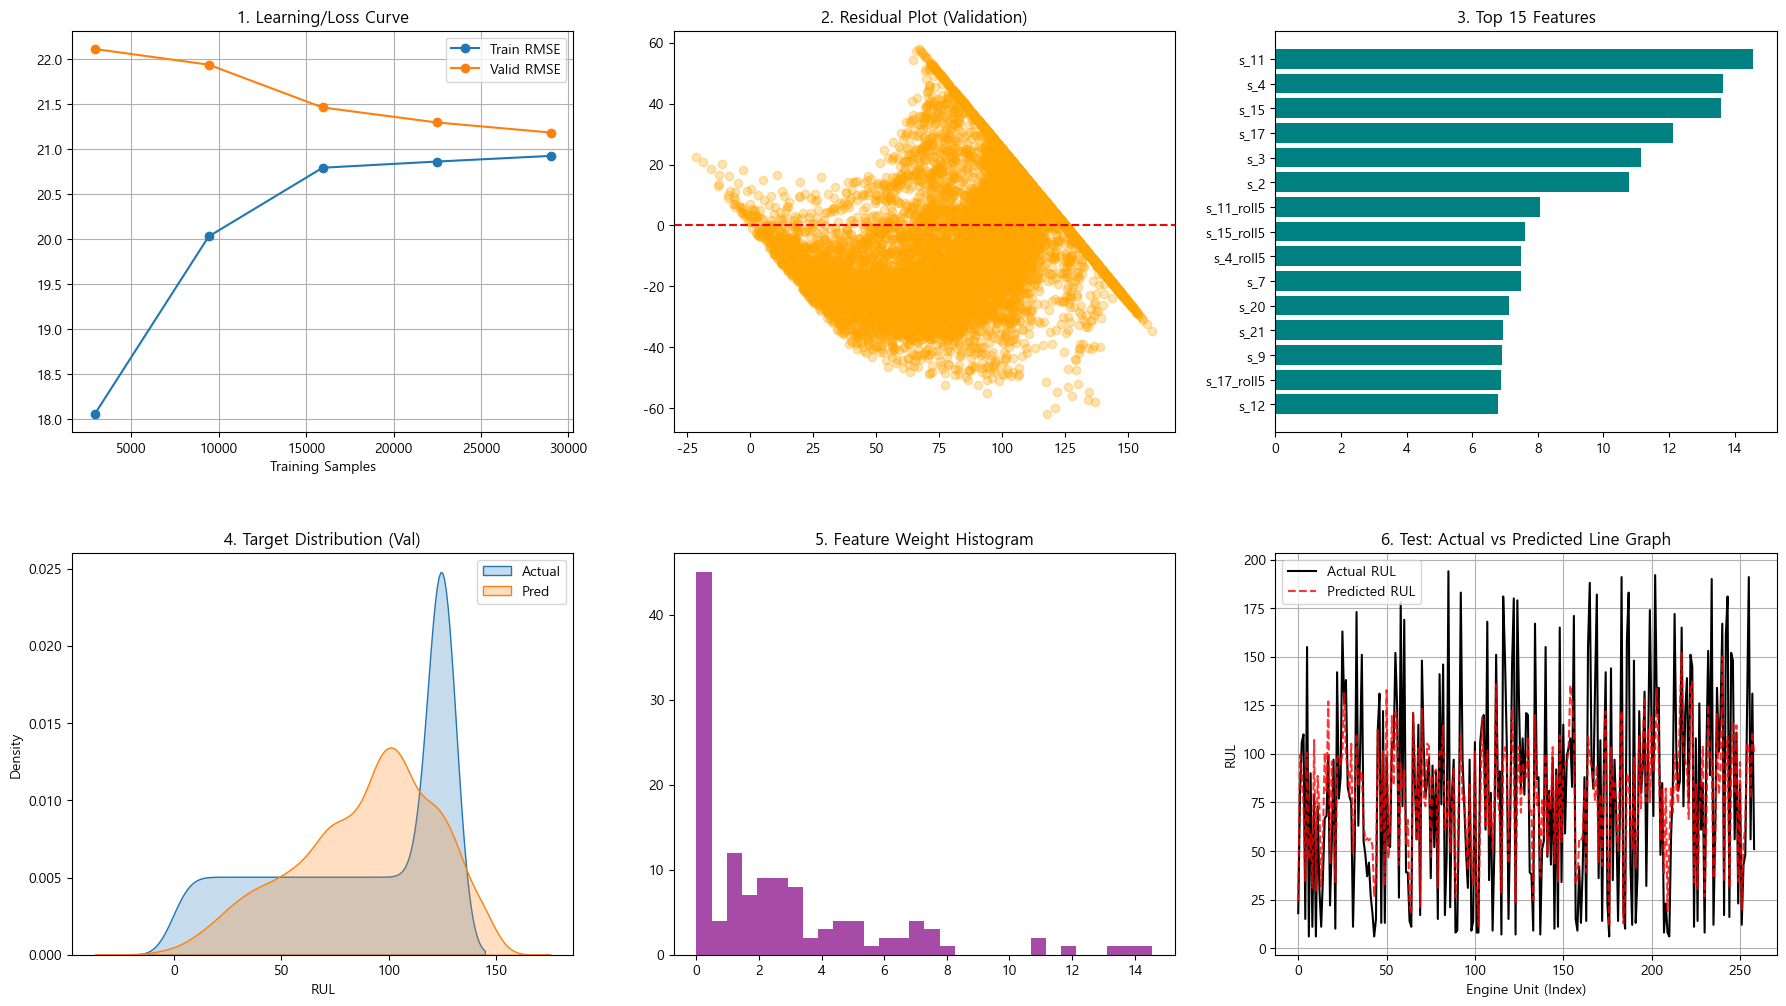

In [11]:
from sklearn.linear_model import ElasticNet

# --- 하이퍼파라미터 설정 ---
elastic_params = {
    'alpha': 0.1,           # 전체 규제 강도
    'l1_ratio': 0.5,        # L1 규제의 비율 (0이면 Ridge, 1이면 Lasso와 동일)
    'selection': 'cyclic',  # 가중치 업데이트 방식
    'max_iter': 2000,       # 최대 반복 횟수
    'tol': 0.0001,          # 수렴 기준
    'random_state': 42
}

# 모델 초기화 및 학습
model_elastic = ElasticNet(**elastic_params)
model_elastic.fit(X_train, y_train)

# 평가 및 시각화
evaluate_full_pipeline(model_elastic, "ElasticNet Regression")


 🏆 Random Forest 최종 평가 결과 
 [Train] RMSE: 11.3610 | NASA Score: 94140.70
 [Valid] RMSE: 13.2969 | NASA Score: 38401.28
 [Test] RMSE: 28.5086 | NASA Score: 9816.01


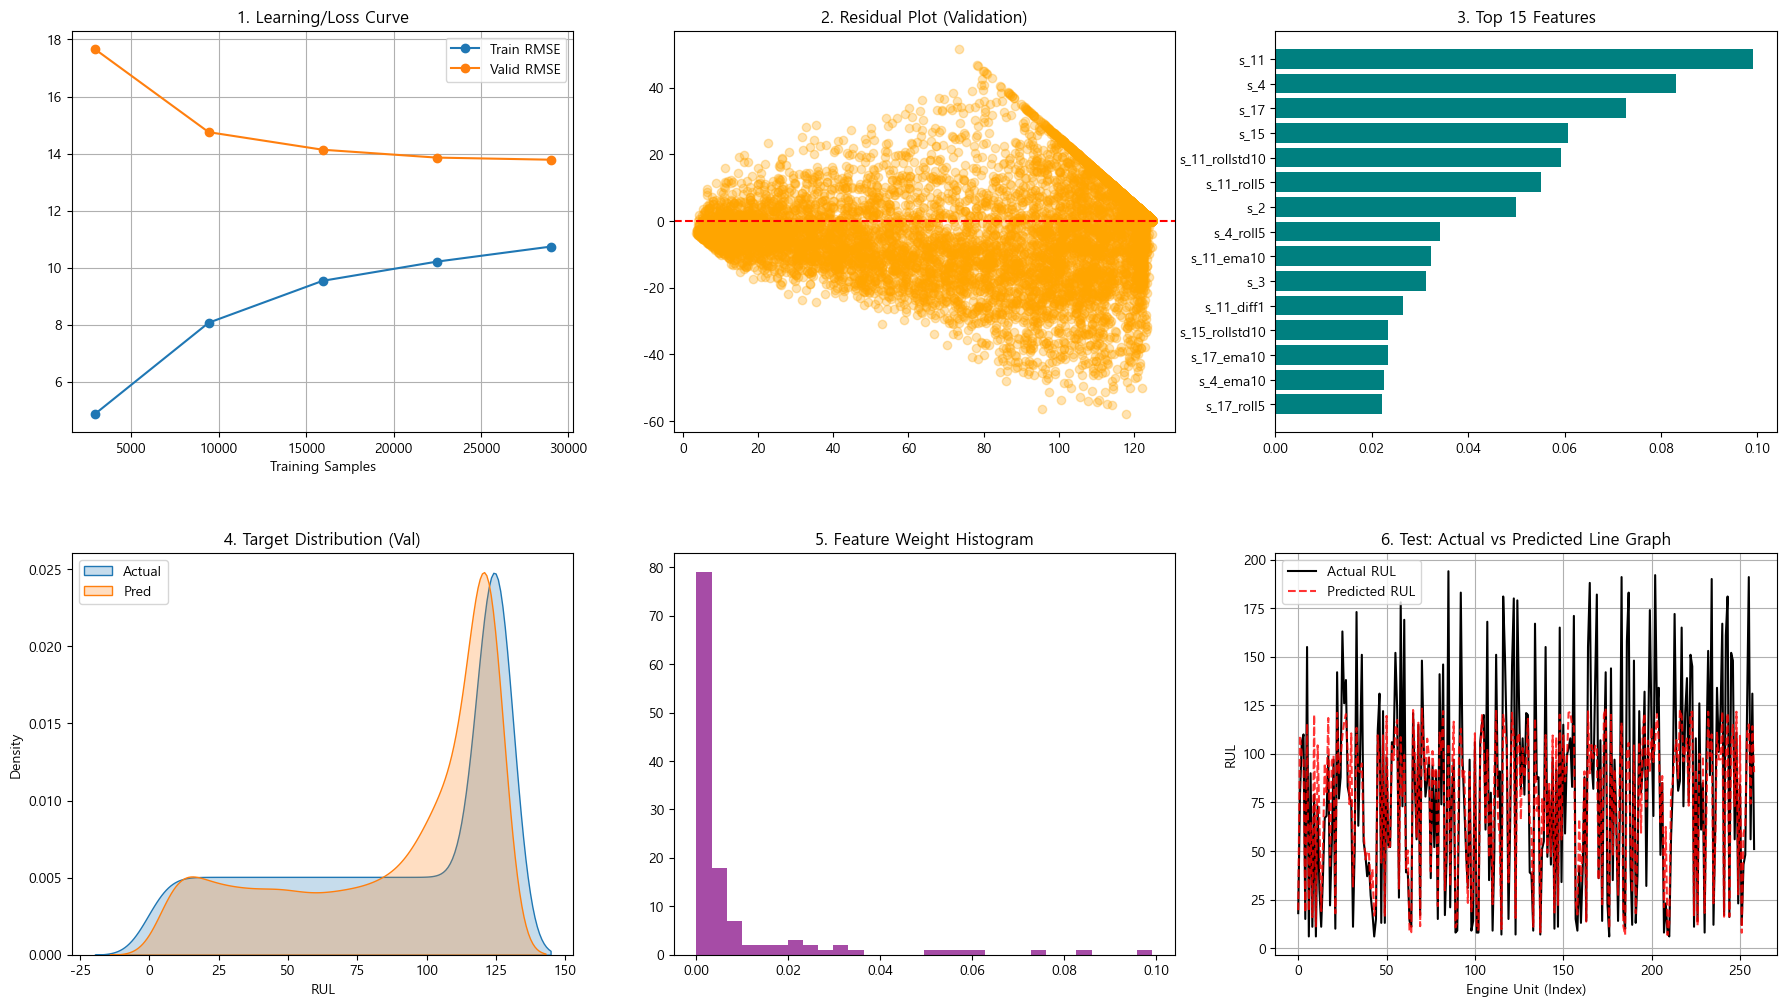

In [12]:
from sklearn.ensemble import RandomForestRegressor

# --- 하이퍼파라미터 설정 ---
rf_params = {
    'n_estimators': 200,      # 생성할 트리의 개수
    'max_depth': 10,          # 트리의 최대 깊이 (과적합 방지)
    'min_samples_split': 5,   # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': 2,    # 리프 노드가 되기 위한 최소 샘플 수
    'max_features': 'sqrt',   # 각 노드에서 분할에 사용할 피처의 비율/개수
    'n_jobs': -1,             # 모든 코어 사용
    'random_state': 42
}

# 모델 초기화 및 학습
model_rf = RandomForestRegressor(**rf_params)
model_rf.fit(X_train, y_train)

# 평가 및 시각화
evaluate_full_pipeline(model_rf, "Random Forest", is_tree=True)


 🏆 XGBoost 최종 평가 결과 
 [Train] RMSE: 6.4033 | NASA Score: 29592.83
 [Valid] RMSE: 12.1896 | NASA Score: 33583.04
 [Test] RMSE: 27.2595 | NASA Score: 7380.92


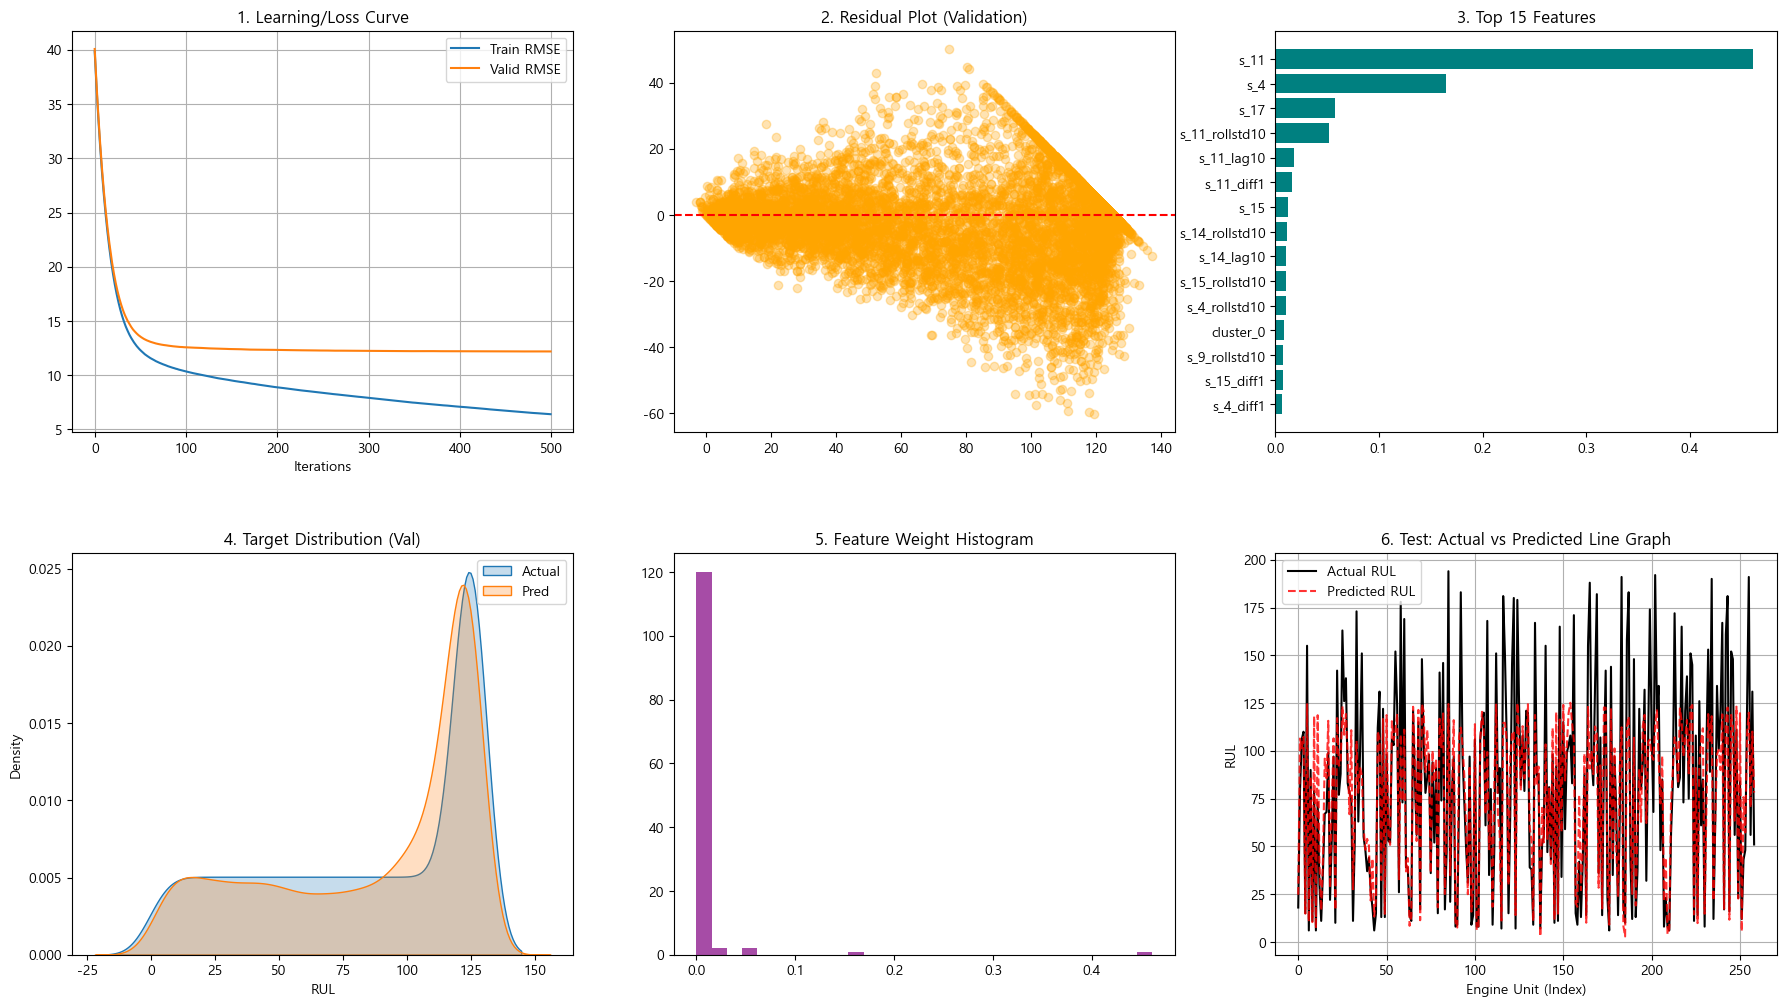

In [13]:
import xgboost as xgb

# --- 하이퍼파라미터 설정 ---
xgb_params = {
    'n_estimators': 500,      # 최대 부스팅 반복 횟수
    'learning_rate': 0.05,    # 학습률 (eta)
    'max_depth': 6,           # 트리의 최대 깊이
    'subsample': 0.8,         # 각 트리마다 데이터 샘플링 비율 (과적합 방지)
    'colsample_bytree': 0.8,  # 각 트리마다 피처 샘플링 비율
    'reg_alpha': 0.1,         # L1 규제 (Lasso 성격)
    'reg_lambda': 1.0,        # L2 규제 (Ridge 성격)
    'random_state': 42,
    'n_jobs': -1
}

# 모델 초기화
model_xgb = xgb.XGBRegressor(**xgb_params)

# 학습 (Early Stopping 적용)
eval_set = [(X_train, y_train), (X_val, y_val)]
model_xgb.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

# 학습 곡선을 위한 Loss 추출
results = model_xgb.evals_result()
eval_dict = {'train': results['validation_0']['rmse'], 'valid': results['validation_1']['rmse']}

# 평가 및 시각화
evaluate_full_pipeline(model_xgb, "XGBoost", is_tree=True, is_boosting=True, eval_results=eval_dict)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008801 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24423
[LightGBM] [Info] Number of data points in the train set: 43464, number of used features: 102
[LightGBM] [Info] Start training from score 87.313639

 🏆 LightGBM 최종 평가 결과 
 [Train] RMSE: 10.7826 | NASA Score: 86298.85
 [Valid] RMSE: 12.6042 | NASA Score: 35400.19
 [Test] RMSE: 27.5123 | NASA Score: 8826.90


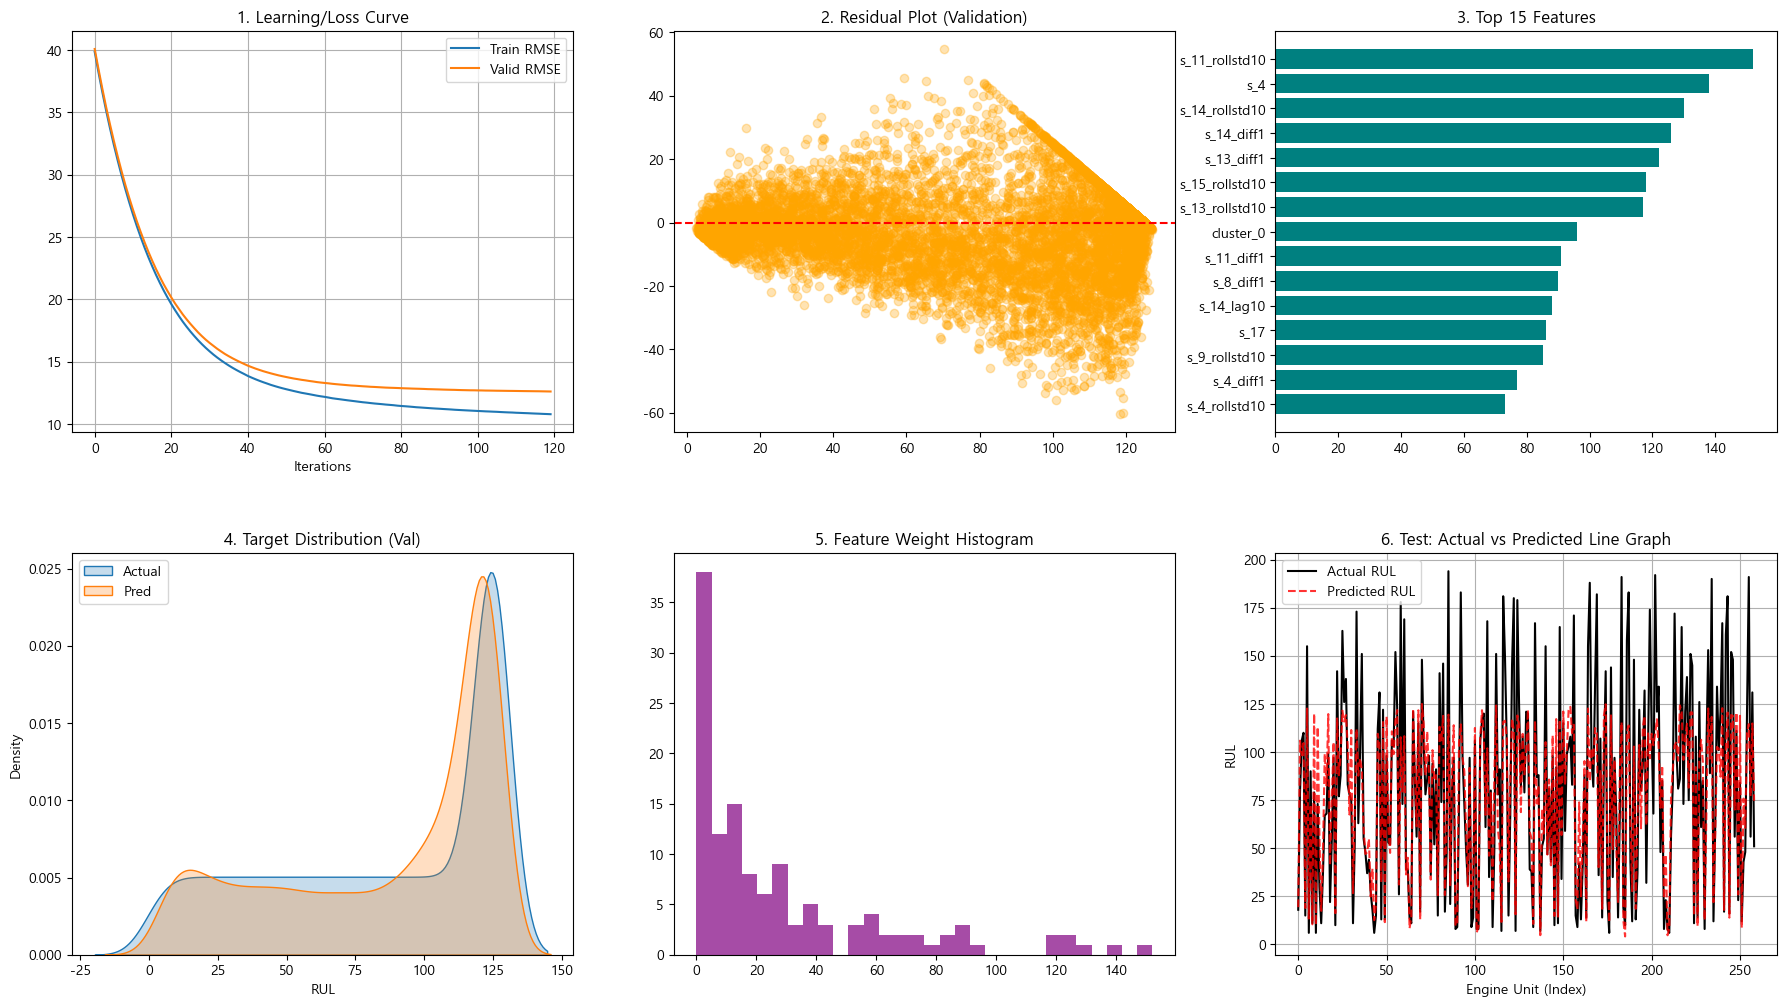

In [14]:
import lightgbm as lgb

# --- 하이퍼파라미터 설정 ---
lgb_params = {
    'n_estimators': 120,      # 최대 부스팅 반복 횟수
    'learning_rate': 0.05,    # 학습률
    'max_depth': 6,           # 트리의 최대 깊이 (-1이면 제한 없음)
    'num_leaves': 31,         # 하나의 트리가 가질 수 있는 최대 리프 수
    'subsample': 0.8,         # 데이터 샘플링 비율 (bagging_fraction)
    'colsample_bytree': 0.8,  # 피처 샘플링 비율 (feature_fraction)
    'reg_alpha': 0.8,         # L1 규제
    'reg_lambda': 0.8,        # L2 규제
    'random_state': 42,
    'n_jobs': -1
}

# 모델 초기화
model_lgb = lgb.LGBMRegressor(**lgb_params)

# 학습 (Early Stopping 적용)
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='rmse'
)

# 학습 곡선을 위한 Loss 추출
results = model_lgb.evals_result_
eval_dict = {'train': results['training']['rmse'], 'valid': results['valid_1']['rmse']}

# 평가 및 시각화
evaluate_full_pipeline(model_lgb, "LightGBM", is_tree=True, is_boosting=True, eval_results=eval_dict)